# Experiment 4 — Cloud Style Comparison

**Goal:** Compare ICP performance across three source cloud geometries:
- `random` — uniform blob (near-spherical symmetry → ICP gets stuck in local minima)
- `clustered` — 8 dense Gaussian clusters (distinct spatial anchors)
- `lattice` — 3-D grid with anisotropic axis spacing (structured, axis-distinguishable)

For each style we visualise the source cloud and evaluate ICP accuracy over 30 random seeds.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from icp import ICP, fit_multi_seed
from synthetic import SyntheticExperiment, CloudStyle
from visualization import PointCloudVisualizer, ErrorMetricsVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

N_SEEDS = 30
SEEDS = list(range(N_SEEDS))
GEN_KWARGS = dict(n=2000, noise_std=3.0, t_scale=8.0)
STYLES = ['random', 'clustered', 'lattice']
COLORS = ['tab:blue', 'tab:orange', 'tab:green']

icp = ICP(max_iter=400, tol=1e-10, verbose=False)

In [2]:
def visualize_cloud(style: CloudStyle, seed: int = 0) -> None:
    """Plot XY, XZ, YZ projections of the source cloud for a given style."""
    exp = SyntheticExperiment.generate(**GEN_KWARGS, seed=seed, style=style)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    PointCloudVisualizer.plot_projections(axes, exp.S)
    fig.suptitle(f'Source cloud — style={style!r}  (n={len(exp.S)})')
    plt.tight_layout()
    plt.savefig(f'../results/4_cloud_styles_{style}_cloud.png', dpi=150, bbox_inches='tight')
    plt.show()

## 1. Random

Points drawn uniformly from $[-30, 30]^3$.  The resulting blob has approximate spherical symmetry — any rotation produces a nearly identical cloud, so nearest-neighbour matching provides no rotational signal and ICP gets trapped in local minima.

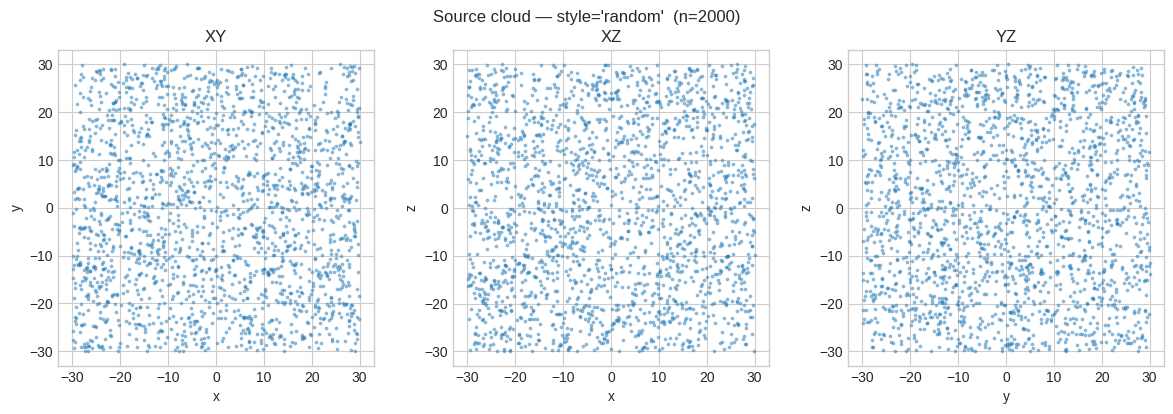

In [3]:
visualize_cloud('random')

Solving 30 seeds: 100%|██████████| 30/30 [00:15<00:00,  1.95it/s]


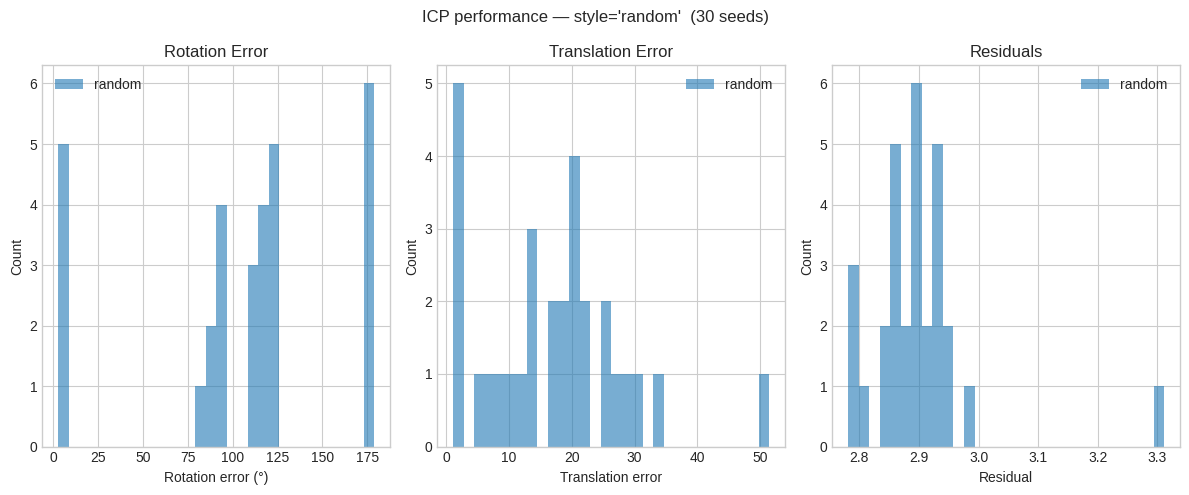

In [4]:
ms_random = fit_multi_seed(icp, SEEDS, experiment_kwargs={**GEN_KWARGS, 'style': 'random'})

fig, axes = ErrorMetricsVisualizer.plot_hists_over_seeds(
    [np.array(ms_random.rotation_errors)],
    [np.array(ms_random.translation_errors)],
    [np.array(ms_random.mean_residuals)],
    method_labels=['random'],
    method_colors=['tab:blue'],
)
fig.suptitle(f"ICP performance — style='random'  ({N_SEEDS} seeds)")
plt.tight_layout()
plt.savefig('../results/4_cloud_styles_random_hists.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Clustered

8 dense Gaussian clusters with centres placed randomly in $[-20, 20]^3$.  Each cluster acts as a distinct spatial anchor: an incorrect rotation that swaps two clusters incurs a large residual, giving ICP a strong signal to correct the alignment.

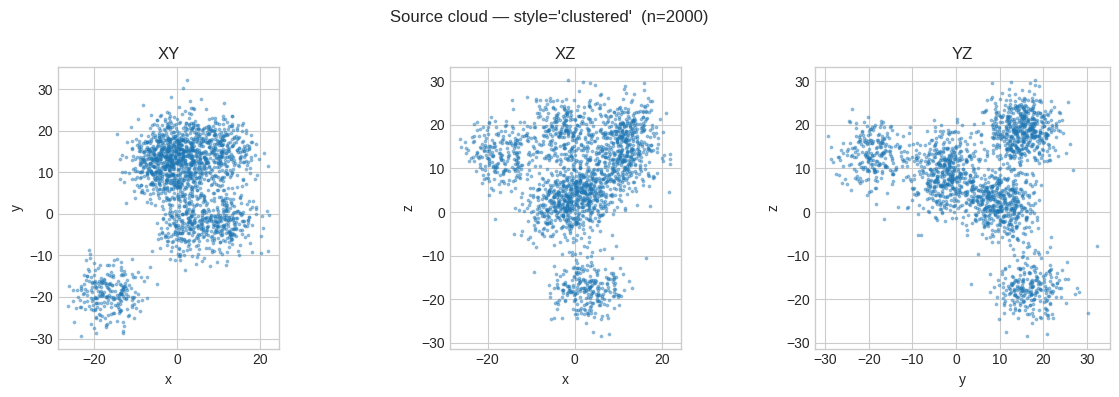

In [5]:
visualize_cloud('clustered')

Solving 30 seeds: 100%|██████████| 30/30 [00:13<00:00,  2.27it/s]


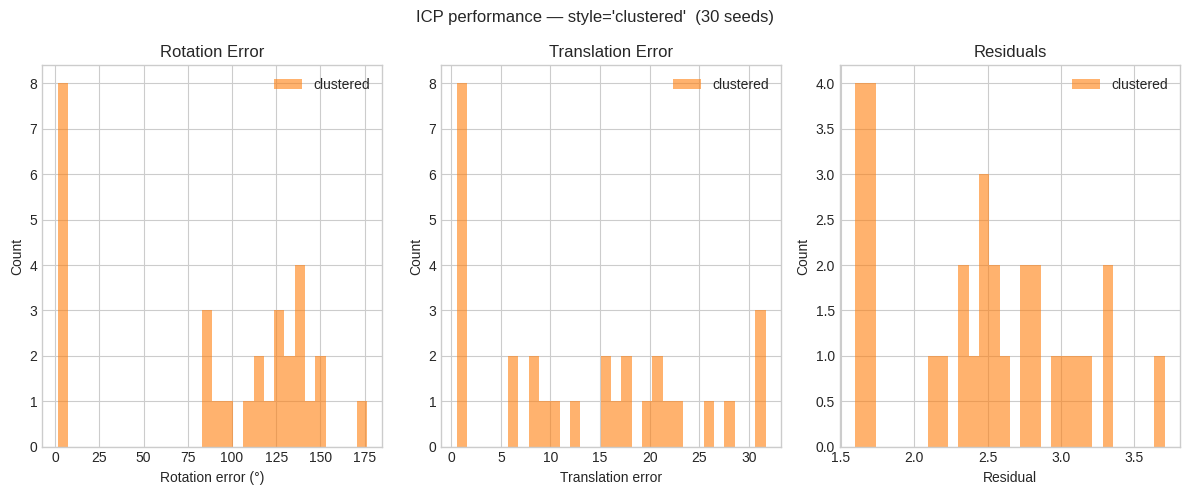

In [6]:
ms_clustered = fit_multi_seed(icp, SEEDS, experiment_kwargs={**GEN_KWARGS, 'style': 'clustered'})

fig, axes = ErrorMetricsVisualizer.plot_hists_over_seeds(
    [np.array(ms_clustered.rotation_errors)],
    [np.array(ms_clustered.translation_errors)],
    [np.array(ms_clustered.mean_residuals)],
    method_labels=['clustered'],
    method_colors=['tab:orange'],
)
fig.suptitle(f"ICP performance — style='clustered'  ({N_SEEDS} seeds)")
plt.tight_layout()
plt.savefig('../results/4_cloud_styles_clustered_hists.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Lattice

3-D regular grid with anisotropic spacing $(2, 3.5, 6)$ along $(x, y, z)$ and slight per-node jitter.  The different spacing per axis makes rotations distinguishable: swapping $x$ and $z$ visibly changes inter-point distances.

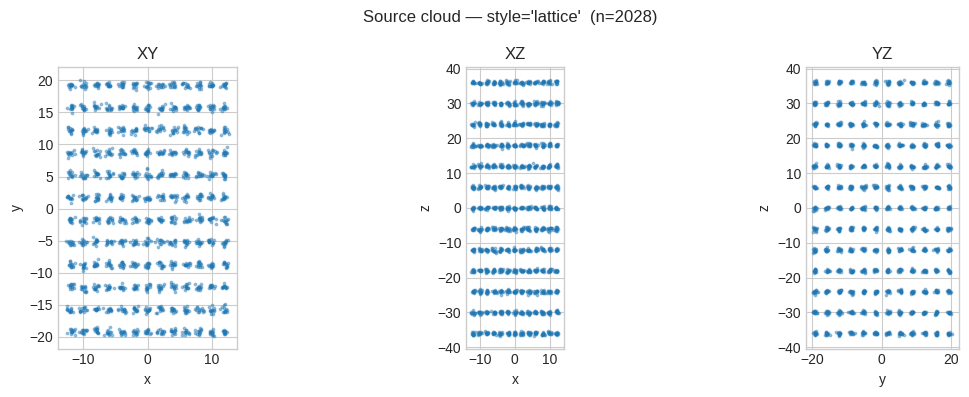

In [7]:
visualize_cloud('lattice')

Solving 30 seeds: 100%|██████████| 30/30 [00:16<00:00,  1.84it/s]


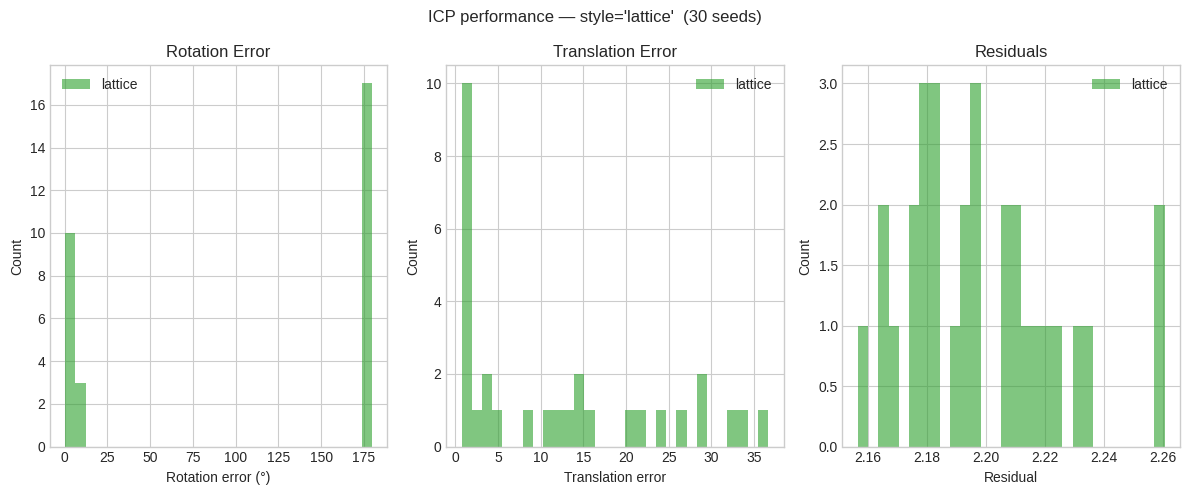

In [8]:
ms_lattice = fit_multi_seed(icp, SEEDS, experiment_kwargs={**GEN_KWARGS, 'style': 'lattice'})

fig, axes = ErrorMetricsVisualizer.plot_hists_over_seeds(
    [np.array(ms_lattice.rotation_errors)],
    [np.array(ms_lattice.translation_errors)],
    [np.array(ms_lattice.mean_residuals)],
    method_labels=['lattice'],
    method_colors=['tab:green'],
)
fig.suptitle(f"ICP performance — style='lattice'  ({N_SEEDS} seeds)")
plt.tight_layout()
plt.savefig('../results/4_cloud_styles_lattice_hists.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Style comparison

All three styles on the same scale.

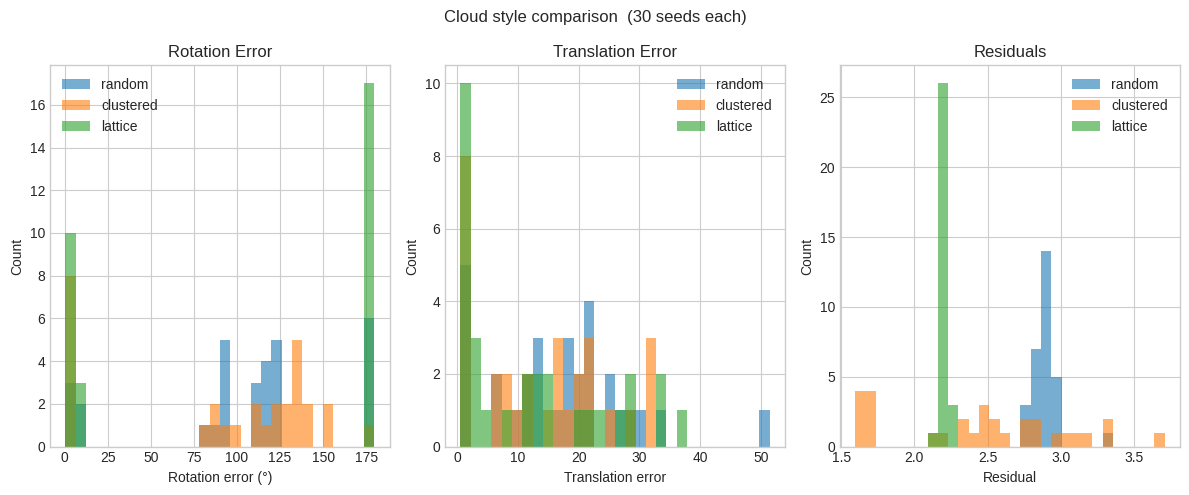

In [9]:
all_ms = {'random': ms_random, 'clustered': ms_clustered, 'lattice': ms_lattice}

fig, axes = ErrorMetricsVisualizer.plot_hists_over_seeds(
    [np.array(all_ms[s].rotation_errors) for s in STYLES],
    [np.array(all_ms[s].translation_errors) for s in STYLES],
    [np.array(all_ms[s].mean_residuals) for s in STYLES],
    method_labels=STYLES,
    method_colors=COLORS,
)
fig.suptitle(f'Cloud style comparison  ({N_SEEDS} seeds each)')
plt.tight_layout()
plt.savefig('../results/4_cloud_styles_comparison.png', dpi=150, bbox_inches='tight')
plt.show()